## Imports e Dataset

In [57]:
import kagglehub
import pandas as pd
import os
import plotly.express as px
import sklearn as sk
import numpy as np
import shap
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Download do dataset
path = kagglehub.dataset_download(
    "dbwaller/official-crime-data-sao-paulo-statebrazil-ssp"
)

# Carregar CSV como DataFrame
file_path = os.path.join(
    path,
    "ds_SSP_CrimeRate_SP-BR_utf8_2001-2020_.csv" # Corrected filename
)

df = pd.read_csv(file_path, sep=';', encoding='utf-8') # Added separator and encoding


Using Colab cache for faster access to the 'official-crime-data-sao-paulo-statebrazil-ssp' dataset.


## Análise de Dataset

In [58]:
df.head()

,Ano,Homicídio Doloso por 100 mil habitantes,Furto por 100 mil habitantes,Roubo por 100 mil habitantes,Furto e Roubo de Veículo por 100 mil habitantes,Furto por 100 mil veículos,Roubo por 100 mil veículos,Furto e Roubo de Veículo por 100 mil veículos,Cidade,Regiao
0,1999.0,"52,58","1.085,19","1.068,39","1.108,17",-,-,-,São Paulo,Capital
1,2000.0,"51,23","1.034,32","1.046,44","1.175,01",-,-,-,São Paulo,Capital
2,2001.0,"49,16","1.099,04","1.066,06","1.032,52","1.423,03","1.275,53","2.698,56",São Paulo,Capital
3,2002.0,"43,63","1.190,92","1.137,27","907,16","1.249,70","1.035,15","2.284,84",São Paulo,Capital
4,2003.0,"39,97","1.333,79","1.237,66","868,17","1.158,55","946,79","2.105,34",São Paulo,Capital


In [59]:
df.dtypes

,0
Ano,float64
Homicídio Doloso por 100 mil habitantes,object
Furto por 100 mil habitantes,object
Roubo por 100 mil habitantes,object
Furto e Roubo de Veículo por 100 mil habitantes,object
Furto por 100 mil veículos,object
Roubo por 100 mil veículos,object
Furto e Roubo de Veículo por 100 mil veículos,object
Cidade,object
Regiao,object


In [60]:

# Homicídio: 52,58 → 52.58
df['Homicídio Doloso por 100 mil habitantes'] = (
    df['Homicídio Doloso por 100 mil habitantes']
    .astype(str)
    .str.replace(',', '.', regex=False)
    .replace('-', np.nan)
    .astype(float)
)

# Demais colunas: 1.085,19 → 1085.19
colunas_br = [
    'Furto por 100 mil habitantes',
    'Roubo por 100 mil habitantes',
    'Furto e Roubo de Veículo por 100 mil habitantes',
    'Furto por 100 mil veículos',
    'Roubo por 100 mil veículos',
    'Furto e Roubo de Veículo por 100 mil veículos'
]

for col in colunas_br:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace('.', '', regex=False)
        .str.replace(',', '.', regex=False)
        .replace('-', np.nan)
        .astype(float)
    )

In [61]:
df.dtypes

,0
Ano,float64
Homicídio Doloso por 100 mil habitantes,float64
Furto por 100 mil habitantes,float64
Roubo por 100 mil habitantes,float64
Furto e Roubo de Veículo por 100 mil habitantes,float64
Furto por 100 mil veículos,float64
Roubo por 100 mil veículos,float64
Furto e Roubo de Veículo por 100 mil veículos,float64
Cidade,object
Regiao,object


In [62]:
df.isna().sum()

,0
Ano,566
Homicídio Doloso por 100 mil habitantes,566
Furto por 100 mil habitantes,566
Roubo por 100 mil habitantes,566
Furto e Roubo de Veículo por 100 mil habitantes,566
Furto por 100 mil veículos,724
Roubo por 100 mil veículos,724
Furto e Roubo de Veículo por 100 mil veículos,724
Cidade,0
Regiao,0


In [63]:
# Colunas de criminalidade
colunas_crime = [
    'Homicídio Doloso por 100 mil habitantes',
    'Furto por 100 mil habitantes',
    'Roubo por 100 mil habitantes',
    'Furto e Roubo de Veículo por 100 mil habitantes',
    'Furto por 100 mil veículos',
    'Roubo por 100 mil veículos',
    'Furto e Roubo de Veículo por 100 mil veículos'
]

# Verificar linhas onde TODAS as variáveis de crime são nulas
linhas_sem_crime = df[df[colunas_crime].isna().all(axis=1)]

print("Linhas sem nenhum indicador de criminalidade:", len(linhas_sem_crime), "\n")
print("Linhas sem nenhum indicador de criminalidade:")
display(linhas_sem_crime)


Linhas sem nenhum indicador de criminalidade: 566 

Linhas sem nenhum indicador de criminalidade:


,Ano,Homicídio Doloso por 100 mil habitantes,Furto por 100 mil habitantes,Roubo por 100 mil habitantes,Furto e Roubo de Veículo por 100 mil habitantes,Furto por 100 mil veículos,Roubo por 100 mil veículos,Furto e Roubo de Veículo por 100 mil veículos,Cidade,Regiao
22,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Arujá,Grande São Paulo (exclui a Capital)
45,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Biritiba Mirim,Grande São Paulo (exclui a Capital)
46,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Caieiras,Grande São Paulo (exclui a Capital)
47,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cajamar,Grande São Paulo (exclui a Capital)
136,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Embu Guaçú,Grande São Paulo (exclui a Capital)
...,...,...,...,...,...,...,...,...,...,...
2299,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,São João de Iracema,Araçatuba
2300,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Sud Mennucci,Araçatuba
2301,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Suzanápolis,Araçatuba
2302,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Turiúba,Araçatuba


In [64]:
df_limpando = df.dropna(subset=colunas_crime, how='all').copy()
df_limpando.isnull().sum()

,0
Ano,0
Homicídio Doloso por 100 mil habitantes,0
Furto por 100 mil habitantes,0
Roubo por 100 mil habitantes,0
Furto e Roubo de Veículo por 100 mil habitantes,0
Furto por 100 mil veículos,158
Roubo por 100 mil veículos,158
Furto e Roubo de Veículo por 100 mil veículos,158
Cidade,0
Regiao,0


In [65]:
df_limpando[
    df_limpando['Furto por 100 mil veículos'].isna()
].groupby('Ano').size()

,0
Ano,
1999.0,79
2000.0,79


In [66]:

colunas_crime = [
    'Homicídio Doloso por 100 mil habitantes',
    'Furto por 100 mil habitantes',
    'Roubo por 100 mil habitantes',
    'Furto e Roubo de Veículo por 100 mil habitantes',
    'Furto por 100 mil veículos',
    'Roubo por 100 mil veículos',
    'Furto e Roubo de Veículo por 100 mil veículos'
]

# Criar um DataFrame combinado para plotagem
# Adicionar uma coluna 'Dataset' para diferenciar o original do limpo
df_original_temp = df[colunas_crime].copy()
df_original_temp['Dataset'] = 'Original'

df_limpando_temp = df_limpando[colunas_crime].copy()
df_limpando_temp['Dataset'] = 'Limpando'

df_combined = pd.concat([df_original_temp, df_limpando_temp])

# Gerar boxplots para cada coluna de criminalidade
print("Gerando boxplots para cada coluna de criminalidade (interativos):")
for col in colunas_crime:
    fig = px.box(df_combined, x='Dataset', y=col, title=f'Comparação de Outliers: {col}',
                 labels={'Dataset': 'Conjunto de Dados', col: 'Valor'})
    fig.show()
#Se mantém os "valores discrepantes", pois são valores que apesar de fora do padrão, são coerentes.

Gerando boxplots para cada coluna de criminalidade (interativos):


# Verificação se as outliers são coerentes ou não

In [67]:
for col in colunas_crime:
    print(f"\n===== {col} ===telek")

    display(
        df_limpando[
            ['Ano', 'Cidade', 'Regiao', col]
        ]
        .sort_values(col, ascending=False)
        .head(10)
    )


===== Homicídio Doloso por 100 mil habitantes ===telek


,Ano,Cidade,Regiao,Homicídio Doloso por 100 mil habitantes
92,1999.0,Diadema,Grande São Paulo (exclui a Capital),102.82
116,2001.0,Embu das Artes,Grande São Paulo (exclui a Capital),93.56
248,1999.0,Itapevi,Grande São Paulo (exclui a Capital),91.45
226,1999.0,Itapecerica da Serra,Grande São Paulo (exclui a Capital),87.32
114,1999.0,Embu das Artes,Grande São Paulo (exclui a Capital),79.15
228,2001.0,Itapecerica da Serra,Grande São Paulo (exclui a Capital),78.65
431,2000.0,Santana de Parnaíba,Grande São Paulo (exclui a Capital),76.78
227,2000.0,Itapecerica da Serra,Grande São Paulo (exclui a Capital),76.17
93,2000.0,Diadema,Grande São Paulo (exclui a Capital),76.15
271,2000.0,Itaquaquecetuba,Grande São Paulo (exclui a Capital),75.98



===== Furto por 100 mil habitantes ===telek


,Ano,Cidade,Regiao,Furto por 100 mil habitantes
1030,2005.0,Barretos,Ribeirão Preto,4053.04
1032,2007.0,Barretos,Ribeirão Preto,3601.00
1029,2004.0,Barretos,Ribeirão Preto,3527.46
1031,2006.0,Barretos,Ribeirão Preto,3351.39
2225,2003.0,Araçatuba,Araçatuba,3335.47
2226,2004.0,Araçatuba,Araçatuba,3279.17
1028,2003.0,Barretos,Ribeirão Preto,3236.78
1033,2008.0,Barretos,Ribeirão Preto,3100.85
1034,2009.0,Barretos,Ribeirão Preto,3023.84
1229,2001.0,Bauru,Bauru,2929.71



===== Roubo por 100 mil habitantes ===telek


...

,Ano,Cidade,Regiao,Furto por 100 mil veículos
1620,2001.0,Praia Grande,Santos,4919.26
1622,2003.0,Praia Grande,Santos,3145.51
1624,2005.0,Praia Grande,Santos,3035.77
1623,2004.0,Praia Grande,Santos,2895.09
1625,2006.0,Praia Grande,Santos,2786.22
1621,2002.0,Praia Grande,Santos,2757.17
1626,2007.0,Praia Grande,Santos,2242.23
362,2001.0,Osasco,Grande São Paulo (exclui a Capital),2092.89
498,2001.0,São Caetano do Sul,Grande São Paulo (exclui a Capital),2044.01
140,2002.0,Ferraz de Vasconcelos,Grande São Paulo (exclui a Capital),2003.58



===== Roubo por 100 mil veículos ===telek


,Ano,Cidade,Regiao,Roubo por 100 mil veículos
272,2001.0,Itaquaquecetuba,Grande São Paulo (exclui a Capital),3626.24
94,2001.0,Diadema,Grande São Paulo (exclui a Capital),3257.76
454,2001.0,Santo André,Grande São Paulo (exclui a Capital),2971.38
455,2002.0,Santo André,Grande São Paulo (exclui a Capital),2756.60
116,2001.0,Embu das Artes,Grande São Paulo (exclui a Capital),2631.46
543,2001.0,Taboão da Serra,Grande São Paulo (exclui a Capital),2404.16
117,2002.0,Embu das Artes,Grande São Paulo (exclui a Capital),2366.31
72,2001.0,Cotia,Grande São Paulo (exclui a Capital),2311.21
456,2003.0,Santo André,Grande São Paulo (exclui a Capital),2220.17
106,2013.0,Diadema,Grande São Paulo (exclui a Capital),2219.10



===== Furto e Roubo de Veículo por 100 mil veículos ===telek


,Ano,Cidade,Regiao,Furto e Roubo de Veículo por 100 mil veículos
1620,2001.0,Praia Grande,Santos,5887.41
272,2001.0,Itaquaquecetuba,Grande São Paulo (exclui a Capital),5510.46
94,2001.0,Diadema,Grande São Paulo (exclui a Capital),4953.42
454,2001.0,Santo André,Grande São Paulo (exclui a Capital),4520.11
543,2001.0,Taboão da Serra,Grande São Paulo (exclui a Capital),4385.97
116,2001.0,Embu das Artes,Grande São Paulo (exclui a Capital),4280.75
455,2002.0,Santo André,Grande São Paulo (exclui a Capital),4132.89
1624,2005.0,Praia Grande,Santos,4116.59
1625,2006.0,Praia Grande,Santos,4073.13
1622,2003.0,Praia Grande,Santos,4001.77


## Construção do Índice de Prioridade Criminal

Para representar o nível relativo de criminalidade dos municípios, foi
construído um índice composto a partir de quatro indicadores:

- Homicídio Doloso por 100 mil habitantes;
- Furto por 100 mil habitantes;
- Roubo por 100 mil habitantes;
- Furto e Roubo de Veículo por 100 mil habitantes.

Os indicadores foram padronizados utilizando Z-score e combinados por
meio de uma soma com pesos iguais.

A utilização de pesos iguais evita a introdução de uma ponderação
subjetiva sobre a gravidade relativa dos diferentes tipos de crime.

As taxas por 100 mil veículos foram excluídas do índice devido à ausência
de cobertura nos anos iniciais do dataset.


In [68]:
colunas_indice = [
    'Homicídio Doloso por 100 mil habitantes',
    'Furto por 100 mil habitantes',
    'Roubo por 100 mil habitantes',
    'Furto e Roubo de Veículo por 100 mil habitantes'
]

In [69]:

treino_mask = df_limpando['Ano'] <= 2015
teste_mask = df_limpando['Ano'] > 2015

scaler = StandardScaler()

for col in colunas_indice:
    z_col = f'z_{col}'

    df_limpando.loc[treino_mask, z_col] = (
        scaler.fit_transform(
            df_limpando.loc[treino_mask, [col]]
        ).ravel()
    )

    df_limpando.loc[teste_mask, z_col] = (
        scaler.transform(
            df_limpando.loc[teste_mask, [col]]
        ).ravel()
    )
    #proteção contra data leakage

In [70]:
## Índices sem pesos para avaliar as diferenças de atuação dos pesos
df_limpando['indice_sem_pesos'] = (
    df_limpando['z_Homicídio Doloso por 100 mil habitantes']
    + df_limpando['z_Furto por 100 mil habitantes']
    + df_limpando['z_Roubo por 100 mil habitantes']
    + df_limpando['z_Furto e Roubo de Veículo por 100 mil habitantes']
)

## Comparação dos modelos por validação cruzada estratificada

In [71]:
# Target com 3 níveis (tercis): Baixa (0), Média (1), Alta (2)
# Limiares calculados SÓ no treino, pra evitar vazamento de dados
treino_temp = df_limpando[df_limpando['Ano'] <= 2015]

limiar_baixa_media = treino_temp['indice_sem_pesos'].quantile(0.33)
limiar_media_alta  = treino_temp['indice_sem_pesos'].quantile(0.66)

def classificar_prioridade(indice):
    if indice < limiar_baixa_media:
        return 0  # Baixa
    elif indice < limiar_media_alta:
        return 1  # Média
    else:
        return 2  # Alta

df_limpando['target_prioridade'] = df_limpando['indice_sem_pesos'].apply(classificar_prioridade)

print("Limiares definidos (baseado só no treino):", limiar_baixa_media, "|", limiar_media_alta)

Limiares definidos (baseado só no treino): -1.1482553894959278 | 0.522694249807508


In [72]:
df_limpando = df_limpando.sort_values(['Cidade', 'Ano'])

for col in colunas_indice:
    df_limpando[f'lag_{col}'] = df_limpando.groupby('Cidade')[col].shift(1)

features_lag = [f'lag_{col}' for col in colunas_indice]

# Remove linhas sem lag (primeiro ano de cada cidade não tem "ano anterior")
df_modelo = df_limpando.dropna(subset=features_lag)

In [73]:
treino = df_modelo[df_modelo['Ano'] <= 2015]
teste  = df_modelo[df_modelo['Ano'] > 2015]

X_treino = treino[features_lag]
y_treino = treino['target_prioridade']
X_teste  = teste[features_lag]
y_teste  = teste['target_prioridade']

print("Colunas usadas como features:", X_treino.columns.tolist())
print("Distribuição treino:\n", y_treino.value_counts(normalize=True))
print("\nDistribuição teste:\n", y_teste.value_counts(normalize=True))

Colunas usadas como features: ['lag_Homicídio Doloso por 100 mil habitantes', 'lag_Furto por 100 mil habitantes', 'lag_Roubo por 100 mil habitantes', 'lag_Furto e Roubo de Veículo por 100 mil habitantes']
Distribuição treino:
 target_prioridade
2    0.335443
0    0.334652
1    0.329905
Name: proportion, dtype: float64

Distribuição teste:
 target_prioridade
0    0.635443
1    0.237975
2    0.126582
Name: proportion, dtype: float64


In [74]:
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=123
)

modelos = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(
            class_weight='balanced',
            max_iter=2000
        ))
    ]),

    'Decision Tree': DecisionTreeClassifier(
        class_weight='balanced',
        random_state=123
    ),

    'Random Forest': RandomForestClassifier(
        class_weight='balanced',
        random_state=123
    ),

    'Gradient Boosting': GradientBoostingClassifier(
        random_state=123
    ),

    'XGBoost': XGBClassifier(
        random_state=123,
        eval_metric='logloss'
    ),

    'SVM': Pipeline([
        ('scaler', StandardScaler()),
        ('model', SVC(
            class_weight='balanced',
            probability=True,
            random_state=123
        ))
    ]),

    'KNN': Pipeline([
        ('scaler', StandardScaler()),
        ('model', KNeighborsClassifier(n_neighbors=5))
    ]),

    'Naive Bayes': GaussianNB()
}

resultados = {}

for nome, modelo in modelos.items():
    scores = cross_val_score(
        modelo,
        X_treino,
        y_treino,
        cv=skf,
        scoring='roc_auc_ovr'
    )

    resultados[nome] = scores

    print(
        f"{nome}: "
        f"AUC médio = {scores.mean():.3f} "
        f"(+/- {scores.std():.3f})"
    )


Logistic Regression: AUC médio = 0.922 (+/- 0.013)
Decision Tree: AUC médio = 0.766 (+/- 0.010)
Random Forest: AUC médio = 0.899 (+/- 0.012)
Gradient Boosting: AUC médio = 0.901 (+/- 0.011)
XGBoost: AUC médio = 0.893 (+/- 0.010)
SVM: AUC médio = 0.918 (+/- 0.012)
KNN: AUC médio = 0.881 (+/- 0.010)
Naive Bayes: AUC médio = 0.870 (+/- 0.018)


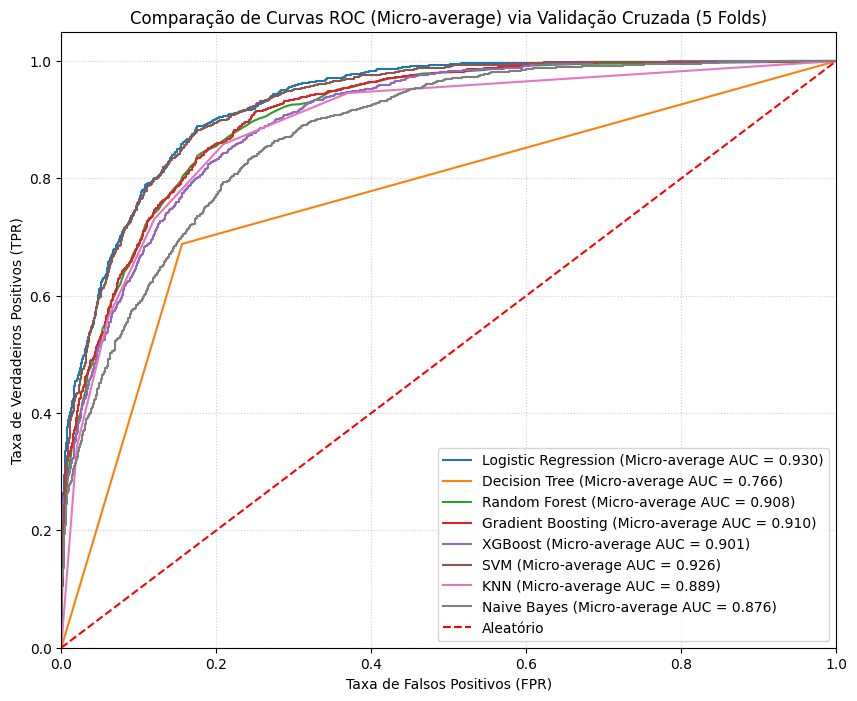

In [75]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 8))

# Get unique classes from y_treino
classes = np.unique(y_treino)
n_classes = len(classes)

for nome, modelo in modelos.items():
    try:
        y_probas = cross_val_predict(
            modelo,
            X_treino,
            y_treino,
            cv=skf,
            method="predict_proba",
        )
    except AttributeError:
        print(f"Skipping {nome} as it does not support predict_proba.")
        continue

    # Binarize y_treino for OvR strategy
    y_treino_binarized = label_binarize(y_treino, classes=classes)

    # Compute micro-average ROC curve and ROC area
    # Flatten the true labels and predicted probabilities for micro-averaging
    fpr_micro, tpr_micro, _ = roc_curve(y_treino_binarized.ravel(), y_probas.ravel())
    auc_micro = auc(fpr_micro, tpr_micro)

    plt.plot(fpr_micro, tpr_micro, label=f"{nome} (Micro-average AUC = {auc_micro:.3f})")

# Plot the diagonal line
plt.plot([0, 1], [0, 1], color="red", linestyle="--", label="Aleatório")

# Customization and finalization of the graph
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("Taxa de Falsos Positivos (FPR)")
plt.ylabel("Taxa de Verdadeiros Positivos (TPR)")
plt.title("Comparação de Curvas ROC (Micro-average) via Validação Cruzada (5 Folds)")
plt.legend(loc="lower right")
plt.grid(True, linestyle=":", alpha=0.6)
plt.show()

In [76]:
df_resultados = pd.DataFrame({
    nome: scores for nome, scores in resultados.items()
}).T
df_resultados.columns = [f'fold_{i+1}' for i in range(5)]
df_resultados['media'] = df_resultados.mean(axis=1)
df_resultados['std'] = df_resultados.std(axis=1)
df_resultados.sort_values('media', ascending=False)

,fold_1,fold_2,fold_3,fold_4,fold_5,media,std
Logistic Regression,0.923809,0.922426,0.897979,0.937098,0.928453,0.921953,0.013039
SVM,0.925686,0.913966,0.895157,0.926052,0.928123,0.917797,0.012363
Gradient Boosting,0.914709,0.897106,0.881726,0.909747,0.903604,0.901379,0.011464
Random Forest,0.906843,0.890907,0.879261,0.905652,0.910608,0.898654,0.011790
XGBoost,0.895258,0.892568,0.872861,0.899104,0.903061,0.892570,0.010473
KNN,0.888641,0.872123,0.869261,0.877902,0.895892,0.880764,0.010061
Naive Bayes,0.852461,0.872149,0.846429,0.889196,0.890542,0.870155,0.018211
Decision Tree,0.777686,0.765656,0.747338,0.765303,0.773810,0.765958,0.010454


===== Logistic Regression =====
              precision    recall  f1-score   support

       Baixa       0.98      0.83      0.90       251
       Média       0.58      0.69      0.63        94
        Alta       0.65      0.90      0.76        50

    accuracy                           0.81       395
   macro avg       0.73      0.81      0.76       395
weighted avg       0.84      0.81      0.81       395



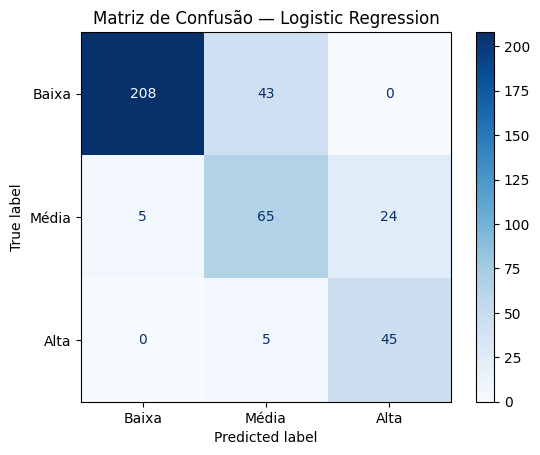

===== Gradient Boosting =====
              precision    recall  f1-score   support

       Baixa       0.95      0.82      0.88       251
       Média       0.52      0.53      0.53        94
        Alta       0.56      0.90      0.69        50

    accuracy                           0.76       395
   macro avg       0.68      0.75      0.70       395
weighted avg       0.80      0.76      0.77       395



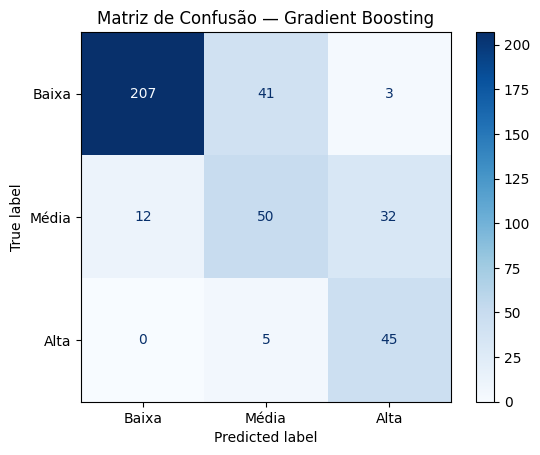

In [77]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

modelos['Logistic Regression'].fit(X_treino, y_treino)
modelos['Gradient Boosting'].fit(X_treino, y_treino)

for nome in ['Logistic Regression', 'Gradient Boosting']:
    modelo = modelos[nome]
    y_pred = modelo.predict(X_teste)

    print(f"===== {nome} =====")
    print(classification_report(y_teste, y_pred, target_names=['Baixa', 'Média', 'Alta']))

    ConfusionMatrixDisplay.from_predictions(
        y_teste, y_pred, display_labels=['Baixa', 'Média', 'Alta'], cmap='Blues'
    )
    plt.title(f"Matriz de Confusão — {nome}")
    plt.show()

## Seleção do modelo

Foram comparados oito algoritmos de classificação utilizando validação
cruzada estratificada (5 folds), com ROC-AUC multiclasse (estratégia
one-vs-rest) como métrica de comparação.

Entre os modelos avaliados, a Regressão Logística apresentou o melhor
desempenho médio em validação cruzada, seguida de perto por SVM e
Gradient Boosting — os três modelos ficaram consistentemente à frente
dos demais algoritmos testados.

No conjunto de teste temporal (2016–2020), a Regressão Logística manteve
o melhor desempenho geral, com acurácia e F1-score macro superiores aos
demais modelos avaliados.

Para a classe "Alta prioridade", a mais relevante dentro do objetivo
deste projeto, o modelo apresentou o maior recall entre os candidatos —
priorizando a identificação de municípios que de fato demandam reforço
policial, mesmo às custas de alguma perda de precisão.

Dessa forma, a Regressão Logística foi selecionada como modelo final,
por equilibrar bom desempenho geral com a métrica mais crítica para o
problema (recall na classe de maior prioridade).

## Aplicação Do modelo

In [78]:
modelo_final = modelos['Logistic Regression']

teste_resultado = teste.copy()

probas = modelo_final.predict_proba(X_teste)

teste_resultado['prob_baixa'] = probas[:, 0]
teste_resultado['prob_media'] = probas[:, 1]
teste_resultado['prob_alta'] = probas[:, 2]

teste_resultado['prioridade_prevista'] = modelo_final.predict(X_teste)

mapa_nomes = {
    0: 'Baixa',
    1: 'Média',
    2: 'Alta'
}

teste_resultado['prioridade_prevista_nome'] = (
    teste_resultado['prioridade_prevista'].map(mapa_nomes)
)

teste_resultado['prioridade_real_nome'] = (
    teste_resultado['target_prioridade'].map(mapa_nomes)
)

ranking = teste_resultado[
    ['Ano', 'Cidade', 'Regiao', 'prob_alta', 'prioridade_prevista_nome', 'prioridade_real_nome']
].sort_values('prob_alta', ascending=False)

display(ranking)

,Ano,Cidade,Regiao,prob_alta,prioridade_prevista_nome,prioridade_real_nome
110,2017.0,Diadema,Grande São Paulo (exclui a Capital),9.999980e-01,Alta,Alta
109,2016.0,Diadema,Grande São Paulo (exclui a Capital),9.999906e-01,Alta,Alta
111,2018.0,Diadema,Grande São Paulo (exclui a Capital),9.999847e-01,Alta,Alta
470,2017.0,Santo André,Grande São Paulo (exclui a Capital),9.999313e-01,Alta,Alta
18,2017.0,São Paulo,Capital,9.999006e-01,Alta,Alta
...,...,...,...,...,...,...
1722,2019.0,Botucatu,Sorocaba,8.159033e-08,Baixa,Baixa
447,2016.0,Santana de Parnaíba,Grande São Paulo (exclui a Capital),7.293750e-08,Baixa,Baixa
1537,2020.0,Bertioga,Santos,6.356142e-08,Baixa,Baixa
449,2018.0,Santana de Parnaíba,Grande São Paulo (exclui a Capital),4.819468e-08,Baixa,Baixa


In [79]:
ranking['prioridade_prevista_nome'].value_counts()

,count
prioridade_prevista_nome,
Baixa,213
Média,113
Alta,69


SHAP --

In [80]:
# Função de predição para o SHAP
def predict_proba_shap(X):
    X_df = pd.DataFrame(X, columns=features_lag)
    return modelo_final.predict_proba(X_df)

explainer = shap.Explainer(
    predict_proba_shap,
    X_treino,
    feature_names=features_lag
)

shap_values = explainer(X_teste)

print(
    "Shape dos valores SHAP:",
    shap_values.values.shape
)

Shape dos valores SHAP: (395, 4, 3)


Cidade: Diadema - Ano: 2017.0
Probabilidade de Alta prioridade: 1.000


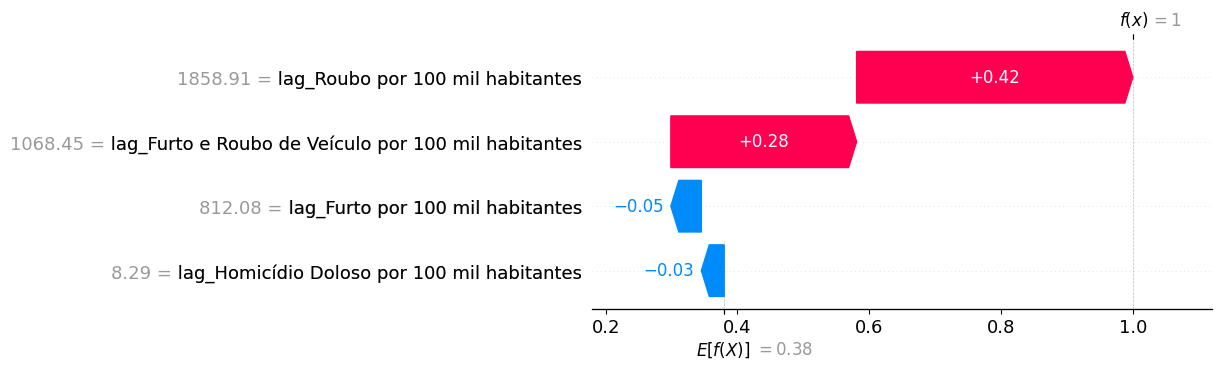

In [81]:
idx_cidade = ranking.index[0]
posicao = X_teste.index.get_loc(idx_cidade)

print(
    f"Cidade: {teste_resultado.loc[idx_cidade, 'Cidade']} "
    f"- Ano: {teste_resultado.loc[idx_cidade, 'Ano']}"
)

print(
    f"Probabilidade de Alta prioridade: "
    f"{teste_resultado.loc[idx_cidade, 'prob_alta']:.3f}"
)

# SHAP da classe "Alta" (classe 2)
shap.waterfall_plot(
    shap_values[posicao, :, 2]
)
#"por que essa cidade, com esses números, recebeu a previsão que recebeu?"

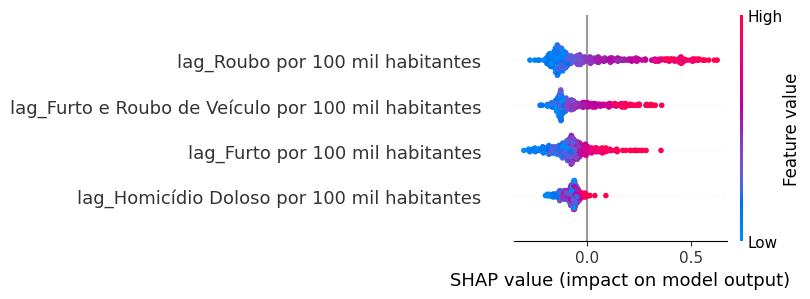

In [82]:
shap.summary_plot(
    shap_values[:, :, 2],
    X_teste,
    feature_names=features_lag
)
#"quais variáveis mais pesam nas decisões do modelo, e em que direção?"